## Route Optimization & Network Analysis
 
Strategic network planning involves identifying capacity imbalances, underutilized lanes, and opportunities for reallocation of resources. This notebook demonstrates actionable optimization techniques.
 
**What you'll discover:**
 - Lane profitability with volume-margin tradeoffs
 - Headhaul vs backhaul imbalances
 - Empty miles identification and reduction strategies
 - Customer concentration risk analysis
 - Seasonal capacity planning
 
**Business impact:** Real companies utilize these exact analyses to achieve millions of dollars in annual savings through network optimization.


In [23]:
from pathlib import Path
import sys

project_root = Path.cwd()
if not (project_root / "src").exists():
    for parent in [project_root, *project_root.parents]:
        if (parent / "src").exists():
            project_root = parent
            break

src_dir = project_root / "src"
if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

print(f"Project root: {project_root}")

Project root: D:\developer\workspace_python\logistics-operations


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')
from logistics_ops.bootstrap import build_tabular_reader

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

reader = build_tabular_reader()

In [25]:
dataset_objects = reader.list_dataset_objects()
print(f"Total de objetos encontrados: {len(dataset_objects)}")
dataset_objects[:10]

Total de objetos encontrados: 16


['raw/kaggle/yogape/logistics-operations-database/.complete/datasets/yogape/logistics-operations-database/1/bundle.complete',
 'raw/kaggle/yogape/logistics-operations-database/DATABASE_SCHEMA.txt',
 'raw/kaggle/yogape/logistics-operations-database/customers.csv',
 'raw/kaggle/yogape/logistics-operations-database/delivery_events.csv',
 'raw/kaggle/yogape/logistics-operations-database/driver_monthly_metrics.csv',
 'raw/kaggle/yogape/logistics-operations-database/drivers.csv',
 'raw/kaggle/yogape/logistics-operations-database/facilities.csv',
 'raw/kaggle/yogape/logistics-operations-database/fuel_purchases.csv',
 'raw/kaggle/yogape/logistics-operations-database/loads.csv',
 'raw/kaggle/yogape/logistics-operations-database/maintenance_records.csv']

In [26]:
csv_object_names = [object_name for object_name in dataset_objects if object_name.endswith(".csv")]
csv_file_names = [Path(object_name).name for object_name in csv_object_names]
csv_file_names

['customers.csv',
 'delivery_events.csv',
 'driver_monthly_metrics.csv',
 'drivers.csv',
 'facilities.csv',
 'fuel_purchases.csv',
 'loads.csv',
 'maintenance_records.csv',
 'routes.csv',
 'safety_incidents.csv',
 'trailers.csv',
 'trips.csv',
 'truck_utilization_metrics.csv',
 'trucks.csv']

In [27]:
dataframes = {}
for file_name in csv_file_names:
    dataframe = reader.read_csv_from_dataset(file_name)
    dataframes[file_name] = dataframe
    print(f"Arquivo: {file_name} | shape={dataframe.shape}")

Arquivo: customers.csv | shape=(200, 8)
Arquivo: delivery_events.csv | shape=(170820, 11)
Arquivo: driver_monthly_metrics.csv | shape=(4464, 9)
Arquivo: drivers.csv | shape=(150, 12)
Arquivo: facilities.csv | shape=(50, 9)
Arquivo: fuel_purchases.csv | shape=(196442, 11)
Arquivo: loads.csv | shape=(85410, 12)
Arquivo: maintenance_records.csv | shape=(2920, 12)
Arquivo: routes.csv | shape=(58, 9)
Arquivo: safety_incidents.csv | shape=(170, 15)
Arquivo: trailers.csv | shape=(180, 9)
Arquivo: trips.csv | shape=(85410, 12)
Arquivo: truck_utilization_metrics.csv | shape=(3312, 10)
Arquivo: trucks.csv | shape=(120, 11)


In [29]:
print("Loading data...")
loads = dataframes['loads.csv']
trips = dataframes['trips.csv']
routes = dataframes['routes.csv']
customers = dataframes['customers.csv']
delivery_events = dataframes['delivery_events.csv']

loads['load_date'] = pd.to_datetime(loads['load_date'])
trips['dispatch_date'] = pd.to_datetime(trips['dispatch_date'])

print(f"Loads: {len(loads):,} records")
print(f"Routes: {len(routes):,} unique lanes")
print(f"Customers: {len(customers):,} accounts")
print("Data loaded successfully!")

Loading data...
Loads: 85,410 records
Routes: 58 unique lanes
Customers: 200 accounts
Data loaded successfully!


## Analysis 1: Lane-Level Profitability Matrix

Identify which routes deserve more capacity vs which should be deprioritized.


Lane Performance Matrix:
margin_tier  Low Margin  Mid Margin  High Margin
volume_tier                                     
Low Volume            6           9            5
Mid Volume            9           4            6
High Volume           5           6            8

Strategic Priorities by Quadrant:

High Volume + High Margin (Protect & Grow):
  8 lanes generating $37,187,450 margin

Low Volume + High Margin (Growth Opportunity):
  5 lanes with expansion potential

High Volume + Low Margin (Repricing Candidates):
  5 lanes needing rate adjustment

Low Volume + Low Margin (Exit Candidates):
  6 lanes to consider exiting


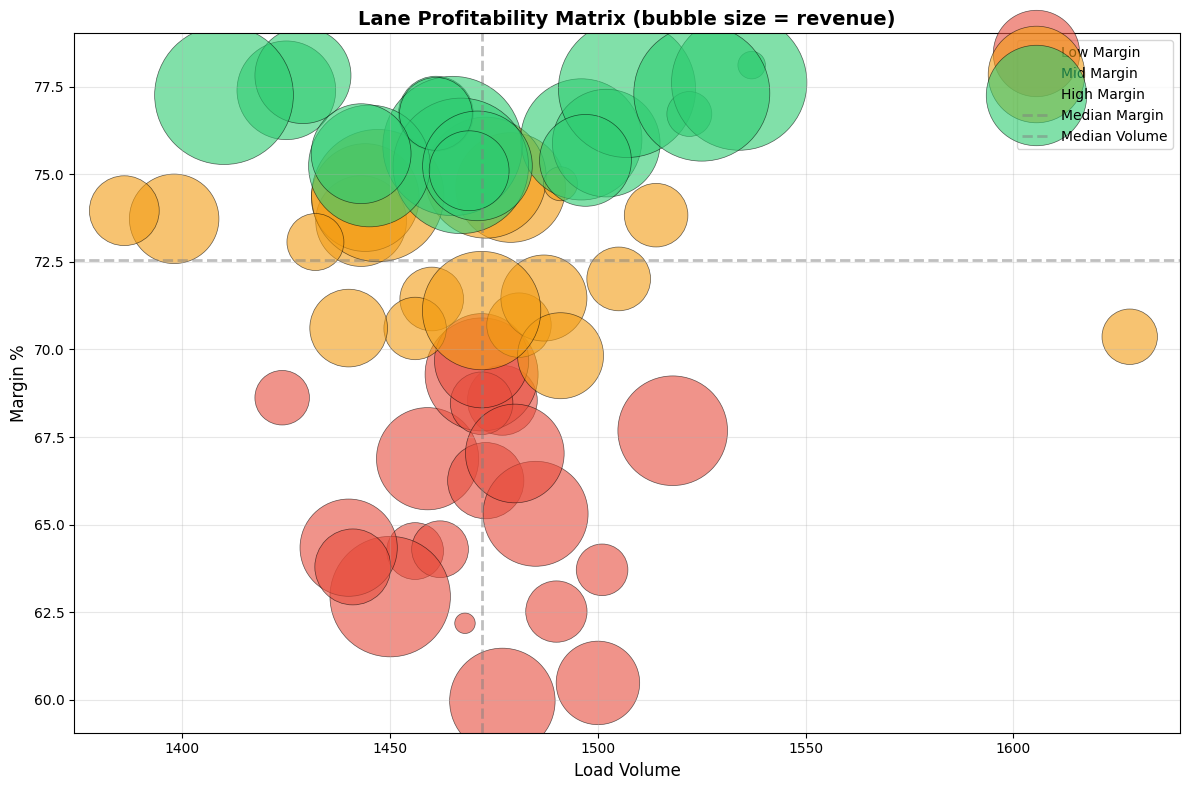

In [30]:
route_analysis = (loads
                  .merge(routes, on='route_id')
                  .merge(trips, on='load_id'))

route_analysis['fuel_cost'] = route_analysis['fuel_gallons_used'] * 3.80
route_analysis['gross_margin'] = route_analysis['revenue'] - route_analysis['fuel_cost']
route_analysis['margin_pct'] = (route_analysis['gross_margin'] / route_analysis['revenue'] * 100)

lane_summary = route_analysis.groupby(['route_id', 'origin_city', 'destination_city']).agg({
    'load_id': 'count',
    'revenue': ['sum', 'mean'],
    'fuel_cost': 'sum',
    'gross_margin': ['sum', 'mean'],
    'margin_pct': 'mean',
    'actual_distance_miles': 'mean'
}).reset_index()

lane_summary.columns = ['route_id', 'origin', 'destination', 'volume', 
                        'total_revenue', 'avg_revenue', 'total_fuel_cost',
                        'total_margin', 'avg_margin', 'margin_pct', 'avg_distance']

lane_summary = lane_summary[lane_summary['volume'] >= 30]

lane_summary['margin_tier'] = pd.qcut(
    lane_summary['margin_pct'], 
    q=3, 
    labels=['Low Margin', 'Mid Margin', 'High Margin']
)

lane_summary['volume_tier'] = pd.qcut(
    lane_summary['volume'],
    q=3,
    labels=['Low Volume', 'Mid Volume', 'High Volume']
)

print("Lane Performance Matrix:")
matrix = pd.crosstab(lane_summary['volume_tier'], lane_summary['margin_tier'], 
                     values=lane_summary['volume'], aggfunc='count')
print(matrix)
print()

print("Strategic Priorities by Quadrant:")
print("\nHigh Volume + High Margin (Protect & Grow):")
protect_grow = lane_summary[
    (lane_summary['volume_tier'] == 'High Volume') & 
    (lane_summary['margin_tier'] == 'High Margin')
]
print(f"  {len(protect_grow)} lanes generating ${protect_grow['total_margin'].sum():,.0f} margin")

print("\nLow Volume + High Margin (Growth Opportunity):")
growth_opp = lane_summary[
    (lane_summary['volume_tier'] == 'Low Volume') & 
    (lane_summary['margin_tier'] == 'High Margin')
]
print(f"  {len(growth_opp)} lanes with expansion potential")

print("\nHigh Volume + Low Margin (Repricing Candidates):")
reprice = lane_summary[
    (lane_summary['volume_tier'] == 'High Volume') & 
    (lane_summary['margin_tier'] == 'Low Margin')
]
print(f"  {len(reprice)} lanes needing rate adjustment")

print("\nLow Volume + Low Margin (Exit Candidates):")
exit_lanes = lane_summary[
    (lane_summary['volume_tier'] == 'Low Volume') & 
    (lane_summary['margin_tier'] == 'Low Margin')
]
print(f"  {len(exit_lanes)} lanes to consider exiting")

plt.figure(figsize=(12, 8))

colors = {
    'Low Margin': '#e74c3c',
    'Mid Margin': '#f39c12',
    'High Margin': '#2ecc71'
}

for margin_tier in lane_summary['margin_tier'].unique():
    subset = lane_summary[lane_summary['margin_tier'] == margin_tier]
    plt.scatter(subset['volume'], subset['margin_pct'], 
               s=subset['total_revenue']/1000, 
               alpha=0.6, 
               label=margin_tier,
               color=colors[margin_tier],
               edgecolors='black',
               linewidth=0.5)

plt.axhline(y=lane_summary['margin_pct'].median(), color='gray', 
            linestyle='--', linewidth=2, alpha=0.5, label='Median Margin')
plt.axvline(x=lane_summary['volume'].median(), color='gray',
            linestyle='--', linewidth=2, alpha=0.5, label='Median Volume')

plt.xlabel('Load Volume', fontsize=12)
plt.ylabel('Margin %', fontsize=12)
plt.title('Lane Profitability Matrix (bubble size = revenue)', fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Analysis 2: Headhaul vs Backhaul Imbalance
 
Directional imbalances create empty miles. Quantifying the gap reveals repositioning costs.

Top 10 Most Imbalanced Markets:
        city  outbound_loads  inbound_loads  net_loads  imbalance_pct            balance_type
Indianapolis             0.0         5810.0    -5810.0     200.000000 Deficit (Need Outbound)
 Los Angeles             0.0         8948.0    -8948.0     200.000000 Deficit (Need Outbound)
     Phoenix          4456.0            0.0     4456.0     200.000000  Surplus (Need Inbound)
     Chicago          5894.0         1456.0     4438.0     120.761905  Surplus (Need Inbound)
   Las Vegas          5865.0         1479.0     4386.0     119.444444  Surplus (Need Inbound)
      Denver          1505.0         5863.0    -4358.0     118.295331 Deficit (Need Outbound)
    Columbus          7620.0         2973.0     4647.0      87.737185  Surplus (Need Inbound)
       Miami          5785.0         2924.0     2861.0      65.702147  Surplus (Need Inbound)
     Detroit          1491.0         2915.0    -1424.0      64.639128 Deficit (Need Outbound)
     Seattle          4430.0

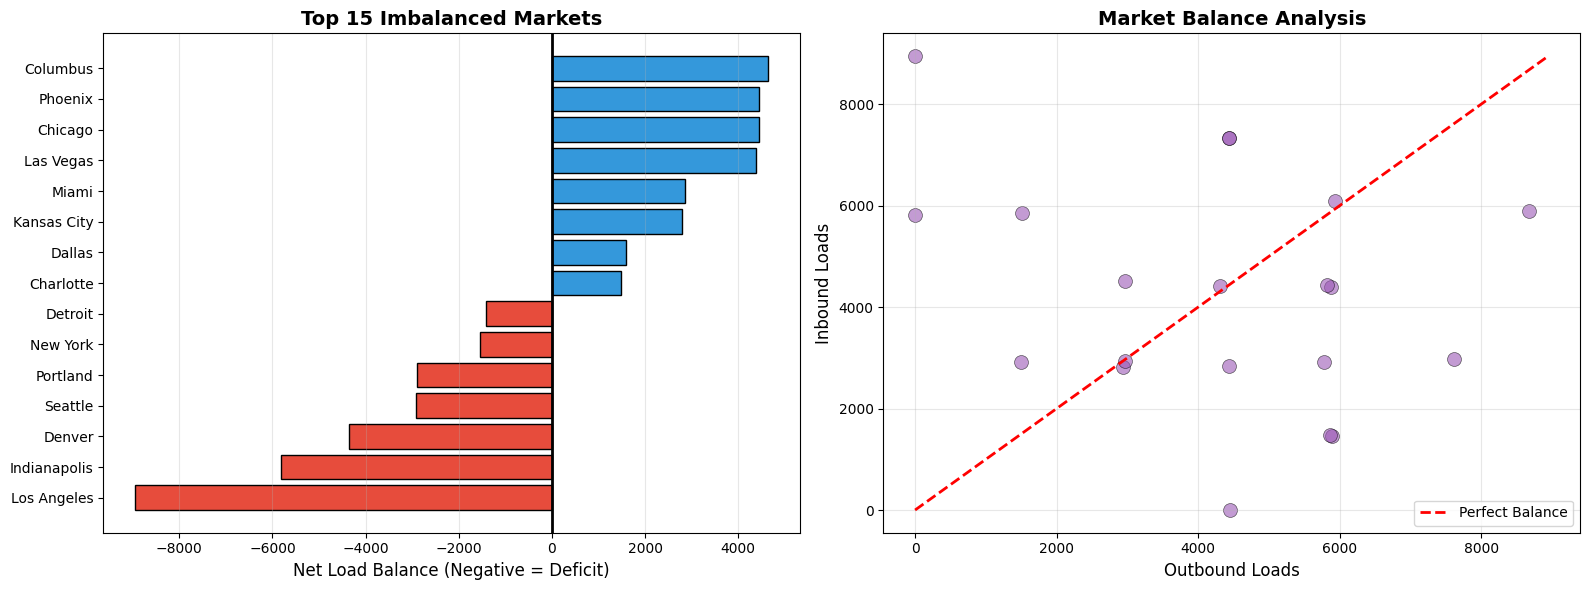

In [31]:
city_outbound = route_analysis.groupby('origin_city').agg({
    'load_id': 'count',
    'revenue': 'sum'
}).reset_index()
city_outbound.columns = ['city', 'outbound_loads', 'outbound_revenue']

city_inbound = route_analysis.groupby('destination_city').agg({
    'load_id': 'count',
    'revenue': 'sum'
}).reset_index()
city_inbound.columns = ['city', 'inbound_loads', 'inbound_revenue']

balance_analysis = city_outbound.merge(city_inbound, on='city', how='outer').fillna(0)

balance_analysis['net_loads'] = balance_analysis['outbound_loads'] - balance_analysis['inbound_loads']
balance_analysis['imbalance_pct'] = abs(balance_analysis['net_loads']) / (
    (balance_analysis['outbound_loads'] + balance_analysis['inbound_loads']) / 2
) * 100

balance_analysis['balance_type'] = balance_analysis['net_loads'].apply(
    lambda x: 'Surplus (Need Inbound)' if x > 0 else 'Deficit (Need Outbound)'
)

print("Top 10 Most Imbalanced Markets:")
imbalanced = balance_analysis.nlargest(10, 'imbalance_pct')[
    ['city', 'outbound_loads', 'inbound_loads', 'net_loads', 'imbalance_pct', 'balance_type']
]
print(imbalanced.to_string(index=False))

estimated_empty_miles = abs(balance_analysis['net_loads'].sum()) * 400
estimated_repositioning_cost = estimated_empty_miles * 0.85
print(f"\nEstimated Annual Empty Miles from Imbalance: {estimated_empty_miles:,.0f}")
print(f"Estimated Annual Repositioning Cost: ${estimated_repositioning_cost:,.0f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_imbalanced = balance_analysis.nlargest(15, 'imbalance_pct').sort_values('net_loads')
colors = ['#e74c3c' if x < 0 else '#3498db' for x in top_imbalanced['net_loads']]

axes[0].barh(top_imbalanced['city'], top_imbalanced['net_loads'], color=colors, edgecolor='black')
axes[0].axvline(x=0, color='black', linewidth=2)
axes[0].set_xlabel('Net Load Balance (Negative = Deficit)', fontsize=12)
axes[0].set_title('Top 15 Imbalanced Markets', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')

axes[1].scatter(balance_analysis['outbound_loads'], balance_analysis['inbound_loads'],
               s=100, alpha=0.6, color='#9b59b6', edgecolors='black', linewidth=0.5)

max_loads = max(balance_analysis['outbound_loads'].max(), balance_analysis['inbound_loads'].max())
axes[1].plot([0, max_loads], [0, max_loads], 'r--', linewidth=2, label='Perfect Balance')
axes[1].set_xlabel('Outbound Loads', fontsize=12)
axes[1].set_ylabel('Inbound Loads', fontsize=12)
axes[1].set_title('Market Balance Analysis', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Analysis 3: Customer Concentration Risk
Overreliance on few customers creates vulnerability. Quantify exposure and diversification needs.


Customer Concentration Analysis:
Top 10 customers: 5.7% of revenue
Top 20 customers: 11.2% of revenue
Total customers: 200

Top 10 Customers by Revenue:
     customer_name customer_type  loads    revenue  revenue_share
         XYZ Foods     Dedicated    476 1544419.81       0.588293
    Superior Group      Contract    497 1542321.02       0.587493
       Metro Group          Spot    487 1521982.07       0.579746
National Wholesale      Contract    470 1487129.31       0.566470
       Metro Foods     Dedicated    463 1483188.90       0.564969
       First Group      Contract    476 1481527.84       0.564336
 Continental Group          Spot    481 1479584.73       0.563596
       United Corp      Contract    460 1477854.32       0.562937
First Supply Chain      Contract    454 1472131.31       0.560757
     XYZ Logistics          Spot    483 1471132.90       0.560377


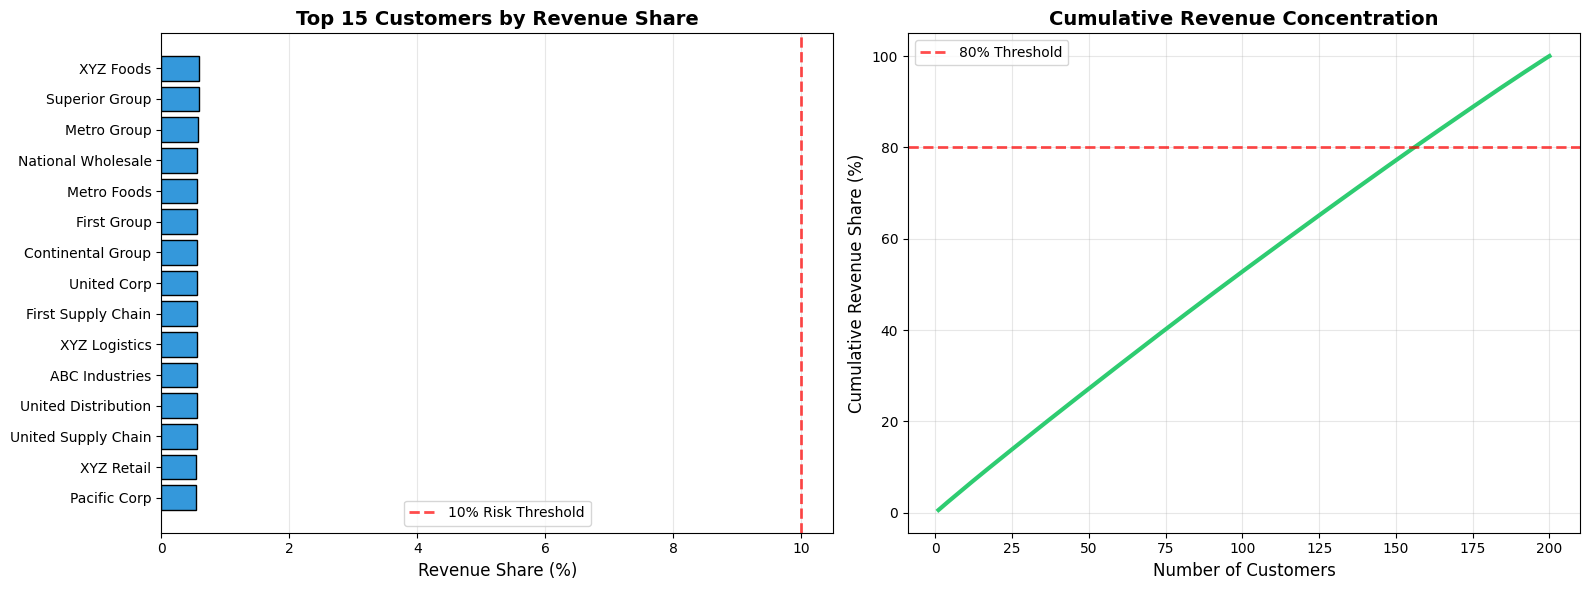

In [32]:
customer_performance = loads.merge(customers, on='customer_id')

customer_summary = customer_performance.groupby(['customer_id', 'customer_name', 'customer_type']).agg({
    'load_id': 'count',
    'revenue': 'sum'
}).reset_index()

customer_summary.columns = ['customer_id', 'customer_name', 'customer_type', 'loads', 'revenue']
customer_summary = customer_summary.sort_values('revenue', ascending=False)

total_revenue = customer_summary['revenue'].sum()
customer_summary['revenue_share'] = (customer_summary['revenue'] / total_revenue * 100)
customer_summary['cumulative_share'] = customer_summary['revenue_share'].cumsum()

top_10_share = customer_summary.head(10)['revenue_share'].sum()
top_20_share = customer_summary.head(20)['revenue_share'].sum()

print("Customer Concentration Analysis:")
print(f"Top 10 customers: {top_10_share:.1f}% of revenue")
print(f"Top 20 customers: {top_20_share:.1f}% of revenue")
print(f"Total customers: {len(customer_summary)}")
print()

print("Top 10 Customers by Revenue:")
print(customer_summary.head(10)[
    ['customer_name', 'customer_type', 'loads', 'revenue', 'revenue_share']
].to_string(index=False))

high_risk_threshold = 10.0
high_risk_customers = customer_summary[customer_summary['revenue_share'] >= high_risk_threshold]

if len(high_risk_customers) > 0:
    print(f"\n  HIGH RISK: {len(high_risk_customers)} customers exceed 10% revenue concentration")
    print(f"Combined exposure: {high_risk_customers['revenue_share'].sum():.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_customers = customer_summary.head(15)
axes[0].barh(range(len(top_customers)), top_customers['revenue_share'], color='#3498db', edgecolor='black')
axes[0].set_yticks(range(len(top_customers)))
axes[0].set_yticklabels([name[:20] for name in top_customers['customer_name']])
axes[0].set_xlabel('Revenue Share (%)', fontsize=12)
axes[0].set_title('Top 15 Customers by Revenue Share', fontsize=14, fontweight='bold')
axes[0].invert_yaxis()
axes[0].axvline(x=10, color='red', linestyle='--', linewidth=2, alpha=0.7, label='10% Risk Threshold')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='x')

axes[1].plot(range(1, len(customer_summary) + 1), customer_summary['cumulative_share'],
            linewidth=3, color='#2ecc71')
axes[1].axhline(y=80, color='red', linestyle='--', linewidth=2, alpha=0.7, label='80% Threshold')
axes[1].set_xlabel('Number of Customers', fontsize=12)
axes[1].set_ylabel('Cumulative Revenue Share (%)', fontsize=12)
axes[1].set_title('Cumulative Revenue Concentration', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Analysis 4: Seasonal Volume Patterns
Understanding seasonal peaks enables proactive capacity planning and rate optimization.


Seasonal Volume Analysis:
Average Monthly Loads: 2372
Peak Month: August 2022 (2,496 loads)
Trough Month: February 2023 (2,136 loads)
Peak-to-Trough Swing: 360 loads (16.9%)

Quarterly Patterns:
  Q1: 21,099.0 loads, $64,908,449 revenue
  Q2: 21,360.0 loads, $65,993,376 revenue
  Q3: 21,484.0 loads, $65,801,076 revenue
  Q4: 21,467.0 loads, $65,822,899 revenue


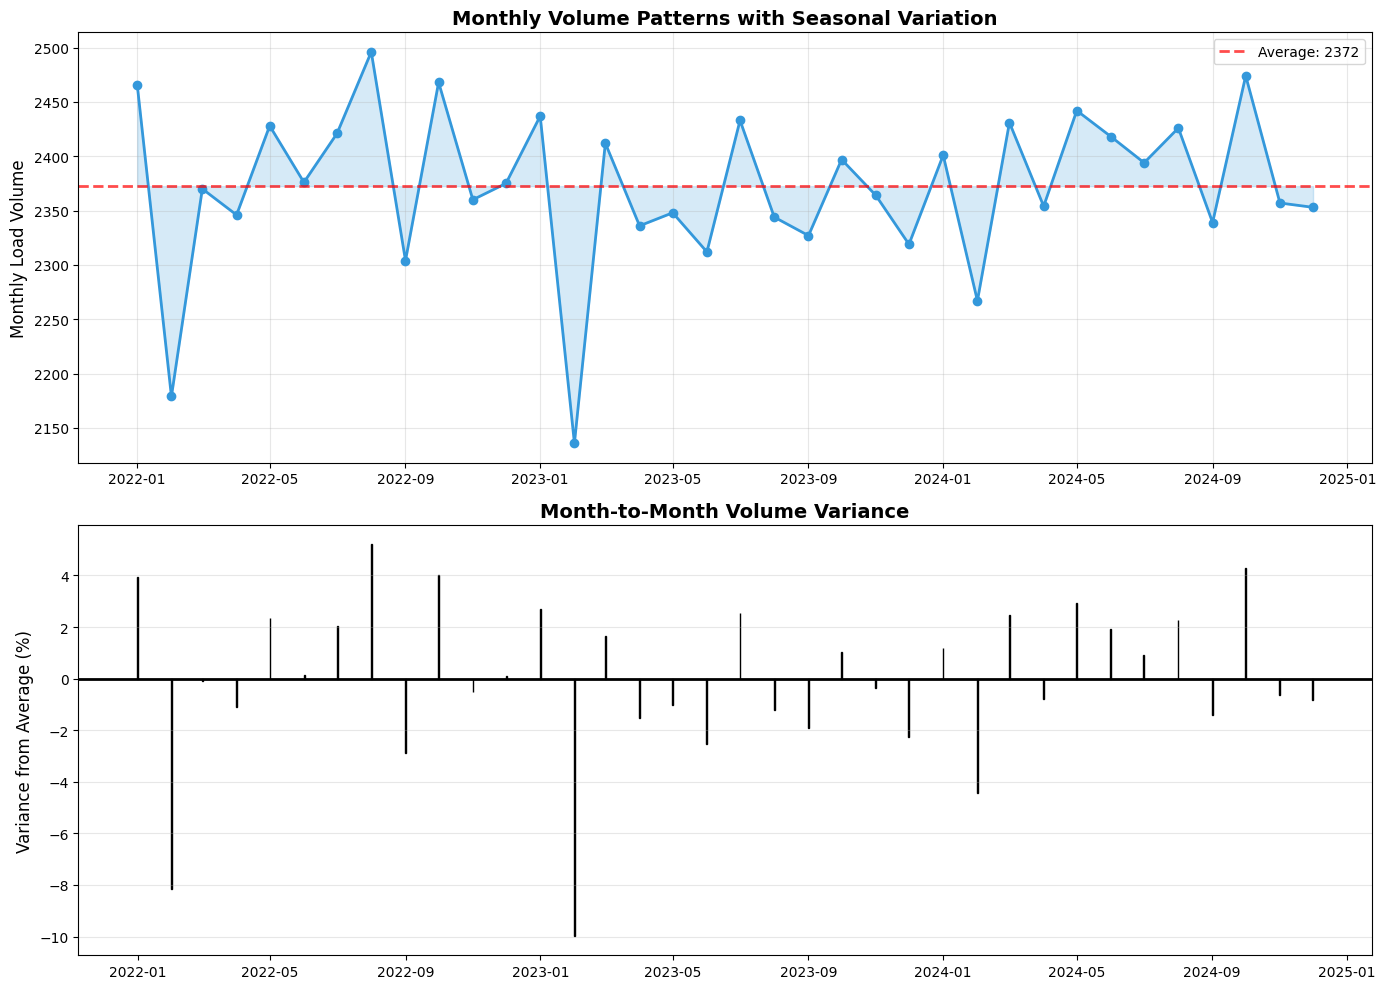

In [33]:
loads['month'] = loads['load_date'].dt.to_period('M')
loads['quarter'] = loads['load_date'].dt.quarter

monthly_volume = loads.groupby('month').agg({
    'load_id': 'count',
    'revenue': 'sum'
}).reset_index()

monthly_volume.columns = ['month', 'loads', 'revenue']
monthly_volume['month'] = monthly_volume['month'].dt.to_timestamp()
monthly_volume['avg_revenue_per_load'] = monthly_volume['revenue'] / monthly_volume['loads']

avg_monthly_loads = monthly_volume['loads'].mean()
monthly_volume['variance_from_avg'] = ((monthly_volume['loads'] - avg_monthly_loads) / avg_monthly_loads * 100)

print("Seasonal Volume Analysis:")
print(f"Average Monthly Loads: {avg_monthly_loads:.0f}")
print(f"Peak Month: {monthly_volume.loc[monthly_volume['loads'].idxmax(), 'month'].strftime('%B %Y')} "
      f"({monthly_volume['loads'].max():,.0f} loads)")
print(f"Trough Month: {monthly_volume.loc[monthly_volume['loads'].idxmin(), 'month'].strftime('%B %Y')} "
      f"({monthly_volume['loads'].min():,.0f} loads)")
print(f"Peak-to-Trough Swing: {monthly_volume['loads'].max() - monthly_volume['loads'].min():,.0f} loads "
      f"({(monthly_volume['loads'].max() / monthly_volume['loads'].min() - 1) * 100:.1f}%)")

quarterly_summary = loads.groupby('quarter').agg({
    'load_id': 'count',
    'revenue': 'sum'
}).reset_index()
quarterly_summary.columns = ['quarter', 'loads', 'revenue']

print("\nQuarterly Patterns:")
for _, row in quarterly_summary.iterrows():
    print(f"  Q{int(row['quarter'])}: {row['loads']:,} loads, ${row['revenue']:,.0f} revenue")

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

axes[0].plot(monthly_volume['month'], monthly_volume['loads'], 
            marker='o', linewidth=2, markersize=6, color='#3498db')
axes[0].axhline(y=avg_monthly_loads, color='red', linestyle='--', 
               linewidth=2, alpha=0.7, label=f'Average: {avg_monthly_loads:.0f}')
axes[0].fill_between(monthly_volume['month'], monthly_volume['loads'], 
                     avg_monthly_loads, alpha=0.2, color='#3498db')
axes[0].set_ylabel('Monthly Load Volume', fontsize=12)
axes[0].set_title('Monthly Volume Patterns with Seasonal Variation', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].bar(monthly_volume['month'], monthly_volume['variance_from_avg'],
           color=['#2ecc71' if x > 0 else '#e74c3c' for x in monthly_volume['variance_from_avg']],
           edgecolor='black')
axes[1].axhline(y=0, color='black', linewidth=2)
axes[1].set_ylabel('Variance from Average (%)', fontsize=12)
axes[1].set_title('Month-to-Month Volume Variance', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Analysis 5: Empty Miles Opportunities
 
Calculate theoretical empty miles and identify potential for repositioning optimization.

Empty Miles Impact Analysis:
Total Loaded Miles: 122,159,201
Estimated Empty Miles (15% rate): 18,323,880
Empty Miles Cost ($0.85/mile): $15,575,298

Optimization Opportunity Analysis:
     Scenario  Empty_Rate  Empty_Miles         Cost      Savings
Current (15%)       0.150 18323880.150 1.557530e+07 0.000000e+00
10% Reduction       0.135 16491492.135 1.401777e+07 1.557530e+06
20% Reduction       0.120 14659104.120 1.246024e+07 3.115060e+06
30% Reduction       0.105 12826716.105 1.090271e+07 4.672589e+06


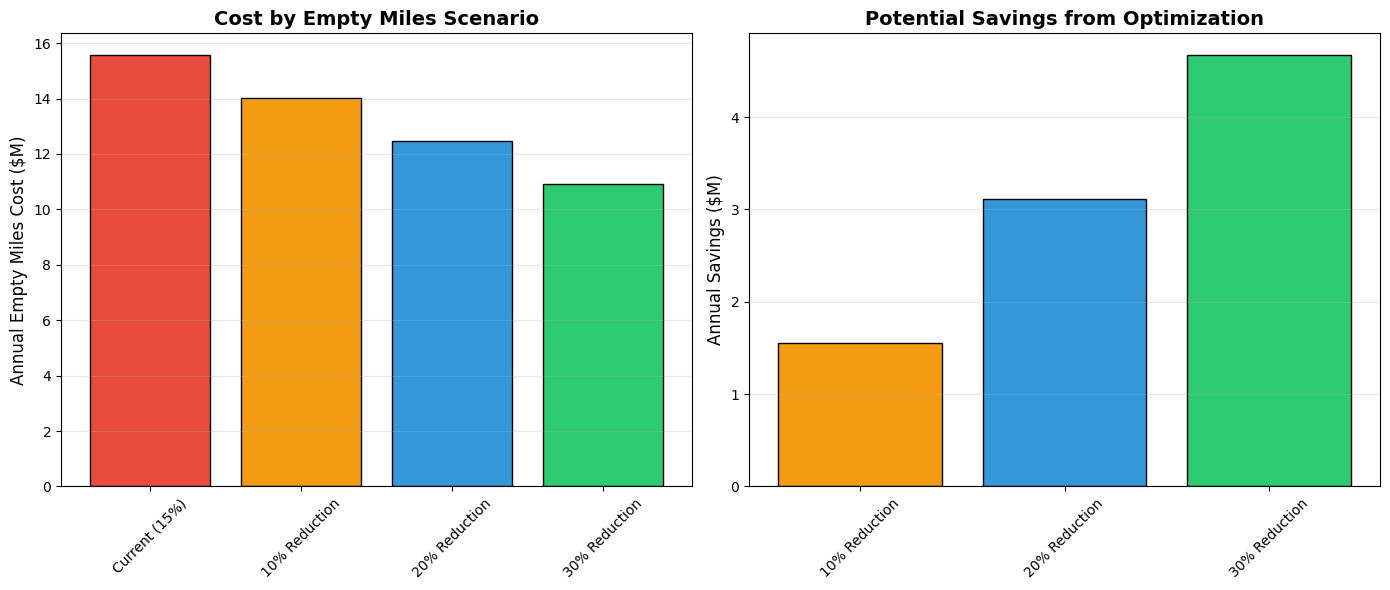


Key Insight: Reducing empty miles from 15% to 10.5% would save $4,672,589 annually


In [34]:
pickup_events = delivery_events[delivery_events['event_type'] == 'Pickup'].copy()
delivery_final = delivery_events[delivery_events['event_type'] == 'Delivery'].copy()

# Simplified empty miles estimate: assume 15% empty miles based on imbalance
total_loaded_miles = trips['actual_distance_miles'].sum()
estimated_empty_miles_rate = 0.15
estimated_empty_miles_total = total_loaded_miles * estimated_empty_miles_rate

empty_cost_per_mile = 0.85
total_empty_cost = estimated_empty_miles_total * empty_cost_per_mile

print("Empty Miles Impact Analysis:")
print(f"Total Loaded Miles: {total_loaded_miles:,.0f}")
print(f"Estimated Empty Miles (15% rate): {estimated_empty_miles_total:,.0f}")
print(f"Empty Miles Cost (${empty_cost_per_mile}/mile): ${total_empty_cost:,.0f}")
print()

improvement_scenarios = pd.DataFrame({
    'Scenario': ['Current (15%)', '10% Reduction', '20% Reduction', '30% Reduction'],
    'Empty_Rate': [0.15, 0.135, 0.12, 0.105],
    'Empty_Miles': [
        estimated_empty_miles_total,
        total_loaded_miles * 0.135,
        total_loaded_miles * 0.12,
        total_loaded_miles * 0.105
    ]
})

improvement_scenarios['Cost'] = improvement_scenarios['Empty_Miles'] * empty_cost_per_mile
improvement_scenarios['Savings'] = total_empty_cost - improvement_scenarios['Cost']

print("Optimization Opportunity Analysis:")
print(improvement_scenarios.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].bar(improvement_scenarios['Scenario'], improvement_scenarios['Cost'] / 1e6,
           color=['#e74c3c', '#f39c12', '#3498db', '#2ecc71'],
           edgecolor='black')
axes[0].set_ylabel('Annual Empty Miles Cost ($M)', fontsize=12)
axes[0].set_title('Cost by Empty Miles Scenario', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')

savings_data = improvement_scenarios[improvement_scenarios['Savings'] > 0]
axes[1].bar(savings_data['Scenario'], savings_data['Savings'] / 1e6,
           color=['#f39c12', '#3498db', '#2ecc71'],
           edgecolor='black')
axes[1].set_ylabel('Annual Savings ($M)', fontsize=12)
axes[1].set_title('Potential Savings from Optimization', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\nKey Insight: Reducing empty miles from 15% to 10.5% would save ${improvement_scenarios.iloc[3]['Savings']:,.0f} annually")


## Strategic Recommendations Summary
Synthesizing findings into actionable network optimization priorities.


In [35]:
print("ROUTE OPTIMIZATION STRATEGIC RECOMMENDATIONS")
print()

print("1. LANE PORTFOLIO MANAGEMENT:")
print(f"   → Protect {len(protect_grow)} high-volume, high-margin lanes")
print(f"   → Grow capacity on {len(growth_opp)} underutilized high-margin lanes")
print(f"   → Reprice {len(reprice)} high-volume but low-margin lanes")
print(f"   → Exit {len(exit_lanes)} low-volume, low-margin lanes")
print()

print("2. BALANCE NETWORK FLOWS:")
print(f"   → Address imbalances in {len(balance_analysis[balance_analysis['imbalance_pct'] > 20])} markets")
print(f"   → Estimated annual savings from rebalancing: ${estimated_repositioning_cost * 0.30:,.0f}")
print()

print("3. CUSTOMER DIVERSIFICATION:")
if len(high_risk_customers) > 0:
    print(f"   →  Reduce concentration risk: {len(high_risk_customers)} customers >10% revenue")
    print(f"   → Target: No single customer exceeding 8% of revenue")
else:
    print(f"   → ✓ Customer concentration within acceptable risk parameters")
print()

print("4. SEASONAL CAPACITY PLANNING:")
peak_month_name = monthly_volume.loc[monthly_volume['loads'].idxmax(), 'month'].strftime('%B')
peak_to_avg_ratio = (monthly_volume['loads'].max() / avg_monthly_loads - 1) * 100
print(f"   → Plan for {peak_to_avg_ratio:.0f}% surge capacity in {peak_month_name}")
print(f"   → Consider flexible capacity (owner-operators, spot market) for peak months")
print()

print("5. EMPTY MILES REDUCTION:")
print(f"   → Current empty miles cost: ${total_empty_cost:,.0f}/year")
print(f"   → Target 20% reduction: ${improvement_scenarios.iloc[2]['Savings']:,.0f}/year savings")
print(f"   → Focus on backhaul load procurement in surplus markets")
print()

total_opportunity = (
    improvement_scenarios.iloc[2]['Savings'] +  # Empty miles reduction
    estimated_repositioning_cost * 0.30  # Rebalancing savings
)

print(f"TOTAL ANNUAL OPPORTUNITY: ${total_opportunity:,.0f}")
print()

ROUTE OPTIMIZATION STRATEGIC RECOMMENDATIONS

1. LANE PORTFOLIO MANAGEMENT:
   → Protect 8 high-volume, high-margin lanes
   → Grow capacity on 5 underutilized high-margin lanes
   → Reprice 5 high-volume but low-margin lanes
   → Exit 6 low-volume, low-margin lanes

2. BALANCE NETWORK FLOWS:
   → Address imbalances in 16 markets
   → Estimated annual savings from rebalancing: $0

3. CUSTOMER DIVERSIFICATION:
   → ✓ Customer concentration within acceptable risk parameters

4. SEASONAL CAPACITY PLANNING:
   → Plan for 5% surge capacity in August
   → Consider flexible capacity (owner-operators, spot market) for peak months

5. EMPTY MILES REDUCTION:
   → Current empty miles cost: $15,575,298/year
   → Target 20% reduction: $3,115,060/year savings
   → Focus on backhaul load procurement in surplus markets

TOTAL ANNUAL OPPORTUNITY: $3,115,060



## Key Takeaways & Next Steps
**What you've learned:**
 - Lane profitability matrix for portfolio management decisions
 - Headhaul/backhaul imbalance quantification and empty miles impact
 - Customer concentration risk assessment and diversification priorities
 - Seasonal volume patterns for capacity planning
 - Optimization opportunity sizing with financial impact
 
**Techniques demonstrated:**
 - Multi-dimensional segmentation (volume × margin matrices)
 - Directional flow analysis for network balancing
 - Concentration risk metrics (Pareto analysis)
 - Time-series decomposition for seasonality
 - Scenario modeling for decision support
 
**Apply these to your projects:**
 - Expand analysis to specific customer segments or freight types
 - Build optimization models for lane selection and pricing
 - Create dynamic capacity allocation algorithms
 - Develop predictive models for demand forecasting
 - Calculate ROI for network restructuring initiatives
 
**Real-world applications:**
 - Network design and lane rationalization
 - Pricing strategy and margin improvement
 - Customer relationship and risk management
 - Capacity planning and asset utilization
 - Strategic planning and business development
 
**Dataset:** [Logistics Operations Database](https://www.kaggle.com/datasets/yogape/logistics-operations-database)
